# Regresión Lineal
Comparación entre ecuación normal y descenso en gradiente.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Datos

In [7]:
n_samples = 100

x = np.random.rand(n_samples, 1) 
y = 4 + 3 * x[:, 0] + np.random.randn(n_samples)

## Ecuación Normal

La solución analítica exacta:

$$w = (X^TX)^{-1}X^Ty$$

Derivada de poner el gradiente del MSE igual a cero y despejar `w`.
No hay iteraciones — es una sola operación matricial.

In [12]:
X = np.column_stack((np.ones(len(x)), x))

def ecuacion_normal(X, y):
  
    #Definir la función
    trans = X.T
    mult = trans @ X
    invertir = np.linalg.inv(mult)
    mult2 = invertir @ trans
    w = mult2 @ y

    return w

w = ecuacion_normal(X, y)

b0 = w[0]
b1 = w[1]

print("Intercepto:", b0)
print("Pendiente:", b1)

Intercepto: 4.316071878514736
Pendiente: 2.651630160509482


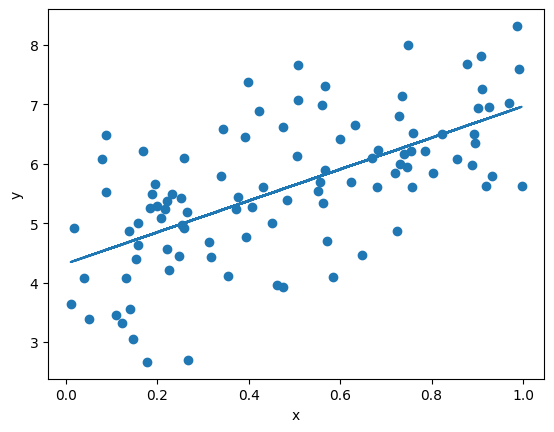

In [14]:
y_pred_normal = X @ w

plt.scatter(x, y)
plt.plot(x, y_pred_normal)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## Descenso en Gradiente

La regla de actualización es:

$$w \leftarrow w - \alpha \cdot \nabla MSE(w)$$

Donde el gradiente del MSE es:

$$\nabla MSE(w) = -\frac{2}{n} X^T(y - Xw)$$

Una sola multiplicación matricial por iteración — mucho más barato que invertir.

In [40]:
def gradiente_descendente(X, y, learning_rate=0.01, epoch=1000, imprimir = True):
    """
    Regresión lineal por Gradiente Descendente (Batch GD).
    
    Actualización: w ← w − α · ∇MSE
    Gradiente:     ∇MSE = −(2/n) · Xᵀ · (y − Xw)
    """
    n, p = X.shape
    w = np.zeros(p)          

    for i in range(epoch):
        # Predicción actual
        ypred = X @ w

        # ∇MSE = −(2/n) · Xᵀ · (y − ŷ)
        gradiente = -(2/n) * (X.T @ (y - ypred))

        # Actualizar pesos
        w = w - learning_rate * gradiente

        if imprimir:
            print(f' Iter {i}: w₀={w[0]}  w₁={w[1]}')
        
    return w

w = gradiente_descendente(X, y)

b0 = w[0]
b1 = w[1]


print("Intercepto:", b0)
print("Pendiente:", b1)

 Iter 0: w₀=0.11181974666450901  w₁=0.058036527794374744
 Iter 1: w₀=0.22084501403445647  w₁=0.11463593179186934
 Iter 2: w₀=0.32714551120470026  w₁=0.16983404435680852
 Iter 3: w₀=0.4307892085210308  w₁=0.2236658041114647
 Iter 4: w₀=0.5318423809494548  w₁=0.2761652782284657
 Iter 5: w₀=0.630369650363727  w₁=0.3273656841671673
 Iter 6: w₀=0.7264340267781135  w₁=0.3772994108678596
 Iter 7: w₀=0.8200969485516932  w₁=0.42599803941733083
 Iter 8: w₀=0.9114183215898524  w₁=0.473492363198974
 Iter 9: w₀=1.0004565575679834  w₁=0.5198124075402935
 Iter 10: w₀=1.087268611201778  w₁=0.5649874488703479
 Iter 11: w₀=1.1719100165878944  w₁=0.6090460333993525
 Iter 12: w₀=1.254434922638187  w₁=0.6520159953323602
 Iter 13: w₀=1.3348961276301063  w₁=0.6939244746286424
 Iter 14: w₀=1.413345112895316  w₁=0.7347979343181009
 Iter 15: w₀=1.489832075668021  w₁=0.7746621773857604
 Iter 16: w₀=1.564405961113966  w₁=0.813542363235114
 Iter 17: w₀=1.637114493560542  w₁=0.8514630237408274
 Iter 18: w₀=1.708004

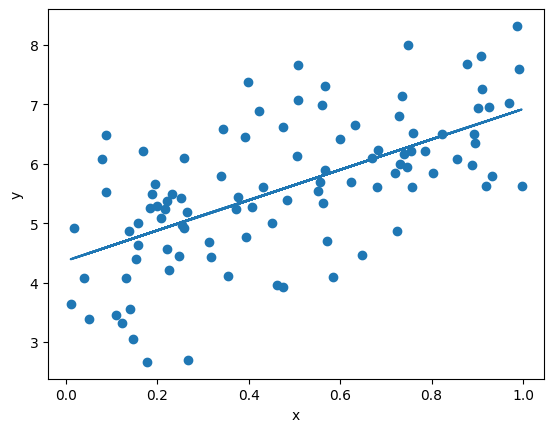

In [41]:
y_pred_gd = b0 + b1 * x

plt.scatter(x, y)
plt.plot(x, y_pred_gd)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## Comparación

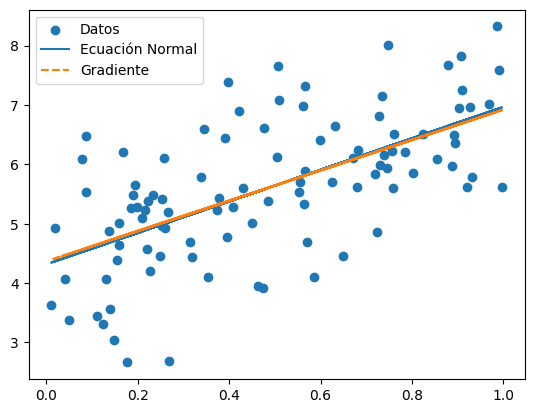

In [42]:
plt.scatter(x, y, label="Datos")
plt.plot(x, y_pred_normal, label="Ecuación Normal")
plt.plot(x, y_pred_gd, linestyle="--", label="Gradiente")

plt.legend()
plt.show()

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor

model =  SGDRegressor()
model

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None


---
# Resumen

| Concepto | Ecuación Normal | Gradiente Descendente |
|----------|----------------|----------------------|
| **Fórmula** | `w = (XᵀX)⁻¹Xᵀy` | `w ← w − α·∇MSE` |
| **Tipo** | Solución exacta | Aproximación iterativa |
| **Hiperparámetros** | Ninguno | `α`, `n_iter` |
| **Costo** | O(p³) en features | O(n·p) por iteración |
| **n grande** | ❌ Lento | ✅ Eficiente (mini-batch) |
| **p grande** | ❌ Imposible | ✅ Funciona |
| **En sklearn** | `LinearRegression()` | `SGDRegressor()` |

---
### ¿Por qué sklearn es rápido?

`LinearRegression()` usa **SVD** (Descomposición en Valores Singulares)  
en vez de invertir directamente — más estable numéricamente y más eficiente.

Para datasets grandes (millones de filas o features), sklearn recomienda `SGDRegressor`.